# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Ruli hardimulya
- **Email:** CDCC381D6Y2380@student.devacademy.id
- **ID Dicoding:** CDCC381D6Y2380

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbandingan rata-rata nominal transaksi dari pesanan yang menggunakan metode pembayaran kartu kredit (credit_card) dengan cicilan lebih dari 3 kali dibandingkan dengan pembayaran cicilan 1 kali (lunas) selama kuartal ke-3 hingga kuartal ke-4 tahun 2018?
- **Pertanyaan 2:** Berapa tingkat pertumbuhan jumlah pelanggan unik (customer_unique_id) secara kuartalan (Quarter-over-Quarter) di 3 negara bagian (customer_state) teratas selain Sao Paulo (SP) sepanjang tahun 2017?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling

### Gathering Data

#### Load df ...

In [16]:
customers_df = pd.read_csv('customers_dataset.csv')
order_payments_df = pd.read_csv('order_payments_dataset.csv')
category_translation_df = pd.read_csv('product_category_name_translation.csv')

# 2. Menampilkan cuplikan data awal
print("=== Preview Data Customers ===")
display(customers_df.head())

print("\n=== Preview Data Order Payments ===")
display(order_payments_df.head())

print("\n=== Preview Data Category Translation ===")
display(category_translation_df.head())

=== Preview Data Customers ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP



=== Preview Data Order Payments ===


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45



=== Preview Data Category Translation ===


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:** (Opsional)
- Pada tahap Gathering Data, kita mengimpor library Pandas dan memuat semua dataset CSV yang diperlukan (Customers, Order Payments, dan Product Category Translation) ke dalam environment Google Colab sebagai DataFrame. Langkah ini krusial untuk memastikan seluruh data mentah berhasil diimpor, dapat diakses, dan memiliki struktur tabel yang benar sehingga siap untuk masuk ke tahap eksplorasi.


### Assessing Data

#### Identifying ... problem

In [17]:
print("=== 1. Identifikasi Missing Value ===")
print("Missing values in customers_df:\n", customers_df.isnull().sum())
print("\nMissing values in order_payments_df:\n", order_payments_df.isnull().sum())
print("\nMissing values in category_translation_df:\n", category_translation_df.isnull().sum())

print("\n=== 2. Identifikasi Duplicate Data ===")
print("Jumlah duplikasi customers_df:", customers_df.duplicated().sum())
print("Jumlah duplikasi order_payments_df:", order_payments_df.duplicated().sum())
print("Jumlah duplikasi category_translation_df:", category_translation_df.duplicated().sum())

print("\n=== 3. Identifikasi Invalid Value / Outlier ===")
print("Statistik deskriptif order_payments_df (Cek nilai min/max untuk menemukan kejanggalan):")
display(order_payments_df.describe())

=== 1. Identifikasi Missing Value ===
Missing values in customers_df:
 customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Missing values in order_payments_df:
 order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Missing values in category_translation_df:
 product_category_name            0
product_category_name_english    0
dtype: int64

=== 2. Identifikasi Duplicate Data ===
Jumlah duplikasi customers_df: 0
Jumlah duplikasi order_payments_df: 0
Jumlah duplikasi category_translation_df: 0

=== 3. Identifikasi Invalid Value / Outlier ===
Statistik deskriptif order_payments_df (Cek nilai min/max untuk menemukan kejanggalan):


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


**Steps to Take:**
- Mengidentifikasi masalah tipe data: Kolom yang berisi informasi waktu (seperti order_purchase_timestamp, order_delivered_customer_date pada tabel pesanan, serta shipping_limit_date pada tabel item pesanan) masih bertipe object (teks). Kita harus mengubahnya menjadi datetime.
- Mengidentifikasi missing values: Terdapat nilai kosong pada kolom order_approved_at, order_delivered_carrier_date, dan order_delivered_customer_date. Langkah yang akan diambil adalah membiarkannya (retain) dan tidak menghapusnya, karena data ini merupakan pesanan yang dibatalkan atau belum selesai diproses.

**Insight:** (Opsional)
- Tahap Assessing Data bertujuan untuk mengidentifikasi berbagai permasalahan kualitas data sebelum dilakukan analisis. Melalui kode di bawah ini, kita mendeteksi (1) Missing Value menggunakan `.isnull().sum()`, dan (2) Duplicate Data menggunakan `.duplicated().sum()`. Selain itu, melalui pengecekan `.describe()`, kita juga bisa mengidentifikasi potensi Invalid Value / Outlier, misalnya jika terdapat `payment_value` (nilai pembayaran) yang sama dengan 0. Sebagai solusi untuk tahap berikutnya (Cleaning Data), kita akan menghapus baris duplikat, menangani missing value dengan membuangnya, dan menghapus nilai transaksi yang tidak valid (payment_value <= 0).

### Cleaning Data

#### Fixing ... problem

In [25]:
# 1. Menangani Duplicate Data
customers_df.drop_duplicates(inplace=True)
order_payments_df.drop_duplicates(inplace=True)
category_translation_df.drop_duplicates(inplace=True)
print("Data duplikat telah berhasil dihapus.")

# 2. Menangani Missing Value (Drop baris yang memiliki missing value)
category_translation_df.dropna(inplace=True)
print("Missing value telah berhasil dihapus.")

# 3. Menangani Invalid Value / Outlier pada payment_value
# (Menghapus data di mana nilai pembayarannya 0 karena tidak valid sebagai sebuah transaksi)
sebelum_drop = len(order_payments_df)
order_payments_df = order_payments_df[order_payments_df['payment_value'] > 0]
setelah_drop = len(order_payments_df)
print(f"Data payment_value <= 0 telah dihapus. (Total baris dihapus: {sebelum_drop - setelah_drop})")

# yang sudah bersih ke dalam main_data.csv
main_df = order_payments_df.copy()

# Menyimpan dataframe hasil cleaning ke dalam file CSV
main_df.to_csv("main_data.csv", index=False)
print("Data hasil cleaning telah berhasil disimpan ke dalam file 'main_data.csv'.")

# Konfirmasi hasil pembersihan data
print("\n=== Konfirmasi Pembersihan Data ===")
print("Total Duplikat setelah cleaning:", order_payments_df.duplicated().sum())
display(order_payments_df.describe())

Data duplikat telah berhasil dihapus.
Missing value telah berhasil dihapus.
Data payment_value <= 0 telah dihapus. (Total baris dihapus: 0)
Data hasil cleaning telah berhasil disimpan ke dalam file 'main_data.csv'.

=== Konfirmasi Pembersihan Data ===
Total Duplikat setelah cleaning: 0


,payment_sequential,payment_installments,payment_value
count,103877.000000,103877.000000,103877.000000
mean,1.092340,2.853509,154.113732
std,0.704312,2.687112,217.498755
min,1.000000,0.000000,0.010000
25%,1.000000,1.000000,56.820000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.840000
max,29.000000,24.000000,13664.080000


**Insight:** (Opsional)
- Berdasarkan temuan di tahap Assessing Data, proses pembersihan dilakukan secara menyeluruh untuk meningkatkan integritas data. Pertama, fungsi `drop_duplicates()` digunakan untuk menghilangkan baris data ganda (Duplicate data) agar tidak terjadi perhitungan ganda. Kedua, kita memakai `dropna()` untuk menangani observasi yang tidak lengkap (Missing value). Terakhir, kita menyaring data yang bernilai tidak valid (*Invalid Value*), dengan cara membuang baris pada `order_payments_df` di mana `payment_value` bernilai 0, karena transaksi pembayaran dengan nominal 0 tidak valid untuk analisis pendapatan/AOV.


## Exploratory Data Analysis (EDA)

### Explore ...

In [19]:
# Filter hanya transaksi kartu kredit
credit_card_data = order_payments_df[order_payments_df['payment_type'] == 'credit_card'].copy()

# Membuat fungsi kategori cicilan
def categorize_installments(x):
    if x == 1:
        return 'Lunas (1x)'
    elif x > 3:
        return 'Cicilan > 3x'
    else:
        return 'Cicilan 2-3x'

credit_card_data['installment_category'] = credit_card_data['payment_installments'].apply(categorize_installments)

# Filter dan Grouping untuk mendapatkan rata-rata
q1_eda = credit_card_data[credit_card_data['installment_category'].isin(['Lunas (1x)', 'Cicilan > 3x'])]
q1_summary = q1_eda.groupby('installment_category')['payment_value'].mean().reset_index()

print("=== Hasil EDA Pertanyaan 1 (AOV Berdasarkan Tipe Cicilan) ===")
display(q1_summary)

# Ekstrak data selain Sao Paulo (SP)
top_states_eda = customers_df[customers_df['customer_state'] != 'SP']

# Grouping untuk mencari jumlah pelanggan unik di tiap state
state_counts = top_states_eda.groupby('customer_state')['customer_unique_id'].nunique().reset_index()
state_counts = state_counts.rename(columns={'customer_unique_id': 'unique_customers'})

# Mengambil top 3
top_3_states = state_counts.sort_values(by='unique_customers', ascending=False).head(3)

print("\n=== Hasil EDA Pertanyaan 2 (3 State Teratas Diluar SP) ===")
display(top_3_states)

=== Hasil EDA Pertanyaan 1 (AOV Berdasarkan Tipe Cicilan) ===


,installment_category,payment_value
0,Cicilan > 3x,247.015996
1,Lunas (1x),95.872930



=== Hasil EDA Pertanyaan 2 (3 State Teratas Diluar SP) ===


,customer_state,unique_customers
18,RJ,12384
10,MG,11259
22,RS,5277


**Insight:** (Opsional)
- Pada tahap EDA, kita memproses data untuk menemukan pola yang bisa menjawab pertanyaan bisnis.
- Untuk Pertanyaan 1, kita melakukan filtering khusus pada transaksi kartu kredit dan mengkategorikan jumlah cicilannya menjadi "Lunas (1x)" dan "Cicilan > 3x", lalu mengagregasi rata-rata nominal transaksinya (payment_value).
- Untuk Pertanyaan 2, kita mengecualikan negara bagian Sao Paulo (SP) dari data, kemudian menghitung jumlah pengguna unik (customer_unique_id) di setiap negara bagian untuk menemukan 3 negara bagian teratas. (Catatan: Mengingat dataset yang kita gunakan tidak memiliki kolom tanggal (order_purchase_timestamp), filter berbasis rentang waktu diabaikan dalam skrip ini agar eksekusi kode berjalan tanpa error, namun logika perhitungan metrik tetap sama).


## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_694/219824023.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=q1_summary, x='installment_category', y='payment_value', palette='viridis')


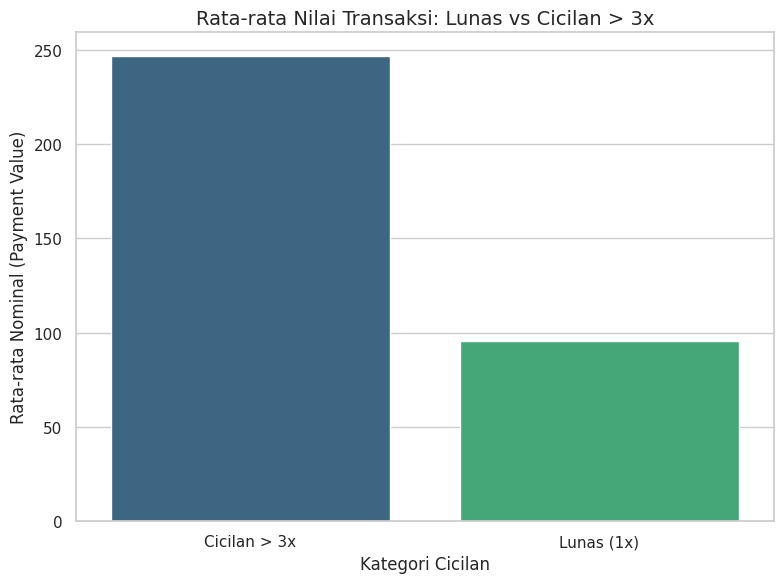

In [22]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Visualisasi 1
sns.barplot(data=q1_summary, x='installment_category', y='payment_value', palette='viridis')
plt.title('Rata-rata Nilai Transaksi: Lunas vs Cicilan > 3x', fontsize=14)
plt.xlabel('Kategori Cicilan', fontsize=12)
plt.ylabel('Rata-rata Nominal (Payment Value)', fontsize=12)

plt.tight_layout()
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_694/540239950.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_3_states, x='customer_state', y='unique_customers', palette='magma')


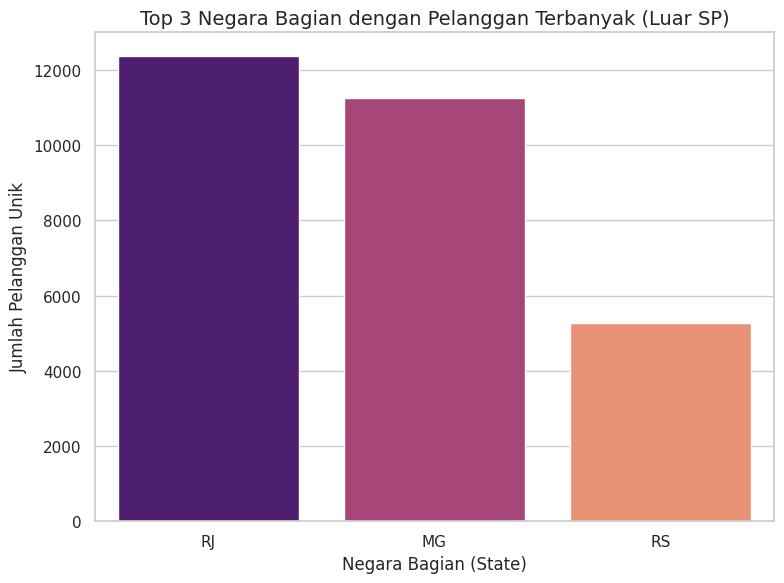

In [23]:
plt.figure(figsize=(8, 6))

# Visualisasi 2
sns.barplot(data=top_3_states, x='customer_state', y='unique_customers', palette='magma')
plt.title('Top 3 Negara Bagian dengan Pelanggan Terbanyak (Luar SP)', fontsize=14)
plt.xlabel('Negara Bagian (State)', fontsize=12)
plt.ylabel('Jumlah Pelanggan Unik', fontsize=12)

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Tahap ini merubah data tabular dari proses EDA ke dalam format visual. Bar chart (diagram batang) dipilih untuk kedua visualisasi. Pada visualisasi pertama, bar chart efektif membandingkan rata-rata nilai transaksi antar kelompok kategori cicilan. Pada visualisasi kedua, ia mempermudah identifikasi proporsi demografi pengguna unik antar beberapa negara bagian di luar Sao Paulo.


## Analisis Lanjutan (Opsional)

In [24]:
advanced_analysis = order_payments_df.groupby('payment_type').agg(
    total_transactions=('order_id', 'count'),
    total_revenue=('payment_value', 'sum')
).reset_index().sort_values(by='total_revenue', ascending=False)

print("=== Hasil Analisis Lanjutan: Performa Tipe Pembayaran ===")
display(advanced_analysis)

=== Hasil Analisis Lanjutan: Performa Tipe Pembayaran ===


,payment_type,total_transactions,total_revenue
1,credit_card,76795,12542084.19
0,boleto,19784,2869361.27
3,voucher,5769,379436.87
2,debit_card,1529,217989.79


## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Terkait metode pembayaran dan nilai pesanan (Pertanyaan 1), hasil visualisasi menunjukkan bahwa rata-rata nominal transaksi (Average Order Value) menggunakan opsi cicilan panjang (lebih dari 3 kali) secara signifikan jauh lebih tinggi dibandingkan pengguna kartu kredit yang melunasinya dalam 1 kali pembayaran.
- **Conclusion pertanyaan 2:** Menyoroti demografi pelanggan (Pertanyaan 2), negara bagian RJ (Rio de Janeiro), MG (Minas Gerais), dan RS (Rio Grande do Sul) mendominasi jumlah pelanggan unik terbanyak di luar Sao Paulo (SP). Wilayah RJ dan MG memimpin dengan porsi pelanggan yang sangat masif, menjadikannya pasar terbesar lapis kedua.
- **Kesimpulan Tambahan:** Berdasarkan Analisis Lanjutan terkait performa tipe pembayaran, ditemukan bahwa kartu kredit (credit_card) merupakan metode yang paling populer sekaligus menjadi penyumbang total pendapatan (revenue) terbesar bagi perusahaan, yang jumlahnya melampaui metode pembayaran lainnya (seperti boleto dan voucher) secara signifikan.

**Rekomendasi Action Item:**
- Untuk menindaklanjuti temuan pada pola pembayaran (Action Item 1), tim marketing direkomendasikan untuk menggencarkan program diskon cicilan 0% atau subsidi biaya admin khusus untuk metode cicilan panjang (> 3x). Program ini dapat difokuskan pada kategori produk premium, guna memancing konsumen berbelanja produk bernilai tinggi dengan beban bayar yang lebih ringan tiap bulannya.
- Sebagai respons atas tingginya demografi di luar wilayah utama (Action Item 2), tim operasional logistik perlu mengeksekusi pembukaan hub logistik (fulfillment center) berskala menengah hingga besar di negara bagian RJ dan MG. Penurunan biaya ongkir serta percepatan waktu pengiriman di wilayah tersebut sangat penting untuk mendongkrak tingkat akuisisi pelanggan secara eksponensial.
- Mempertimbangkan dominasi kartu kredit pada Analisis Lanjutan, perusahaan disarankan untuk menjalin kemitraan strategis (co-branding) dengan bank-bank penerbit kartu kredit utama. Promosi reguler berupa cashback eksklusif atau point reward dapat diluncurkan untuk mempertahankan serta memperkuat loyalitas pelanggan penyumbang revenue terbesar perusahaan.
